In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/2) Stock Prices Data Set.csv")

Mounted at /content/drive


In [ ]:
df.shape

(497472, 7)

In [ ]:
df.isnull().sum()

,0
symbol,0
date,0
open,11
high,8
low,8
close,0
volume,0


In [ ]:
duplicate_rows = df[df.duplicated()]
print(f"\n No of duplicate rows: {duplicate_rows.shape[0]}")


 No of duplicate rows: 0


In [ ]:
# Feature & Target
x=df[['open']]
y= df['close']

In [ ]:
from sklearn.model_selection import train_test_split
# Train Test
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size = 0.2, random_state=42)


In [ ]:
df = df.dropna(subset=['high', 'low', 'open'])

In [ ]:
df.isnull().sum()

,0
symbol,0
date,0
open,0
high,0
low,0
close,0
volume,0


In [ ]:
x_train.isna().sum()

,0
open,0


In [ ]:
x_train = x_train.dropna()
y_train = y_train[x_train.index]

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
print("Coefficient: ", model.coef_[0])
print("Intercept: ", model.intercept_)

Coefficient:  0.999955775040792
Intercept:  0.020651064718379075


In [ ]:
x_test.isna().sum()

,0
open,0


In [ ]:
x_test = x_test.dropna()
y_test = y_test[x_test.index]

In [ ]:
# Predic
from sklearn.metrics import r2_score, mean_squared_error
y_pred = model.predict(x_test)
# model
print("R-Squre: ", r2_score(y_test,y_pred))
print("Mean error: ", mean_squared_error(y_test,y_pred))

R-Squre:  0.999745180712254
Mean error:  2.6417107500773342


In [ ]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
print(df.columns)

Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'], dtype='object')


In [ ]:
# Row index to time index
df.index = pd.RangeIndex(start=0, stop=len(df), step=1)

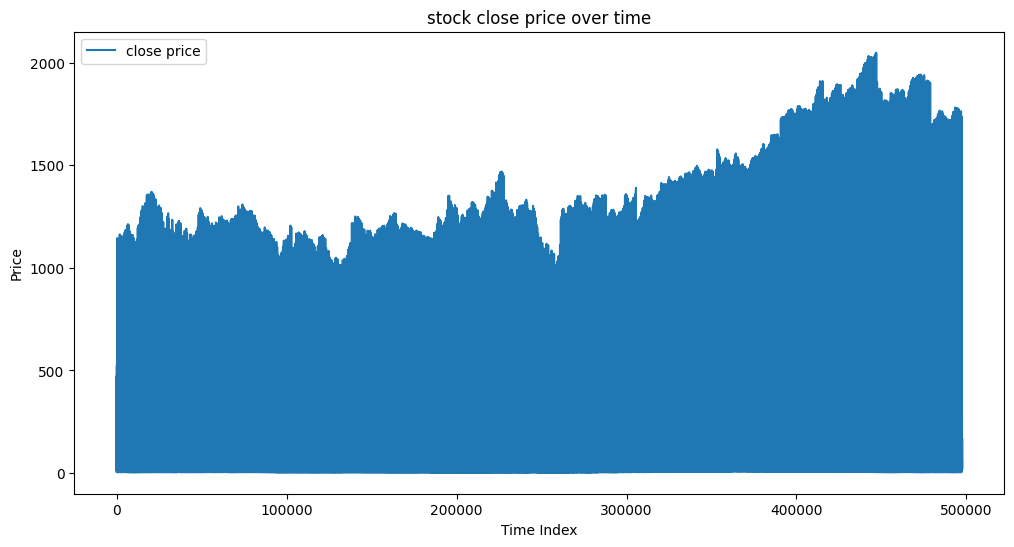

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df['close'], label='close price')
plt.title('stock close price over time')
plt.xlabel('Time Index')
plt.ylabel("Price")
plt.legend()
plt.show()

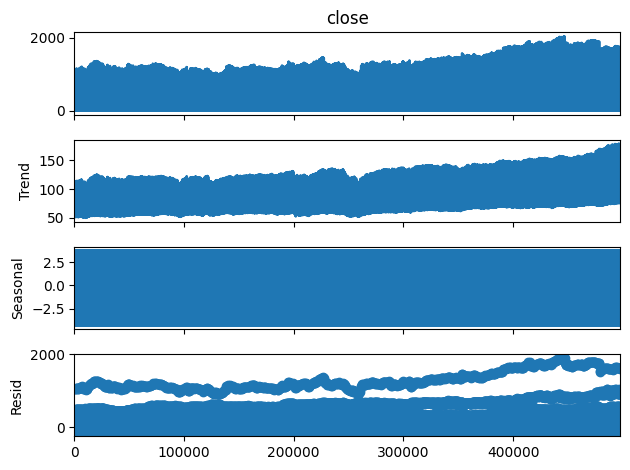

In [ ]:
# Dcompose
result = seasonal_decompose(df['close'], model='additive', period=30)
result.plot()
plt.show()

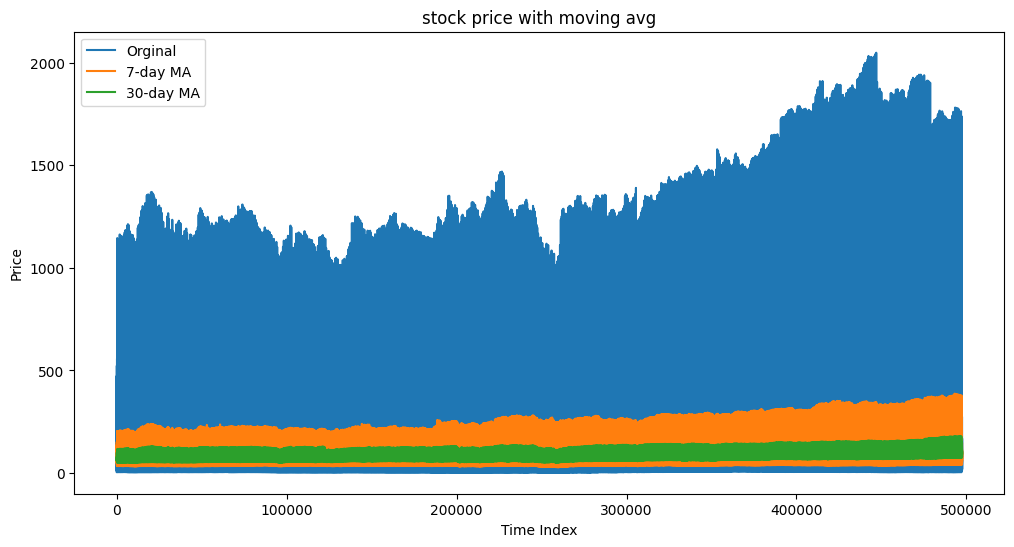

In [ ]:
# 7 day
df['ma_7'] = df['close'].rolling(window=7).mean()
# 30 day
df['ma_30'] = df['close'].rolling(window=30).mean()

plt.figure(figsize=(12,6))
plt.plot(df['close'], label='Orginal')
plt.plot(df['ma_7'], label='7-day MA')
plt.plot(df['ma_30'], label='30-day MA')
plt.title('stock price with moving avg')
plt.xlabel('Time Index')
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
df = pd.read_csv("/content/1) iris.csv")

In [ ]:
df.shape

(150, 5)

In [ ]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


In [ ]:
duplicate_rows = df[df.duplicated()]
print(f"\n No of duplicate rows: {duplicate_rows.shape[0]}")


 No of duplicate rows: 3


In [ ]:
df = df.drop_duplicates()

In [ ]:
import seaborn as sn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
# standerdize
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


In [ ]:
import numpy as np
np.isnan(x_scaled).sum()

np.int64(0)

In [ ]:
import pandas as pd
x_scaled = pd.DataFrame(x_scaled).dropna().values

/tmp/ipykernel_411/4232079103.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


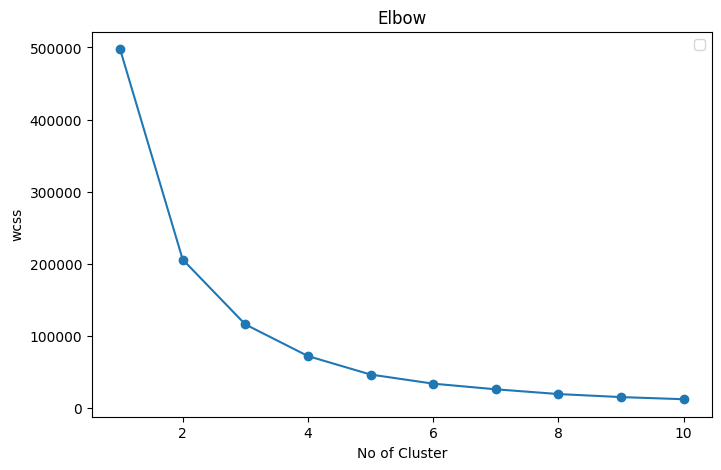

In [ ]:
# Elbow
import matplotlib.pyplot as plt
wcss = []
for k in range(1,11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(x_scaled)
  wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow')
plt.xlabel('No of Cluster')
plt.ylabel("wcss")
plt.legend()
plt.show()


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
df = pd.read_csv("/content/1) iris.csv")

df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")
df = df.drop_duplicates()
X = df.drop('species', axis=1)

In [ ]:
# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# KMeans
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters

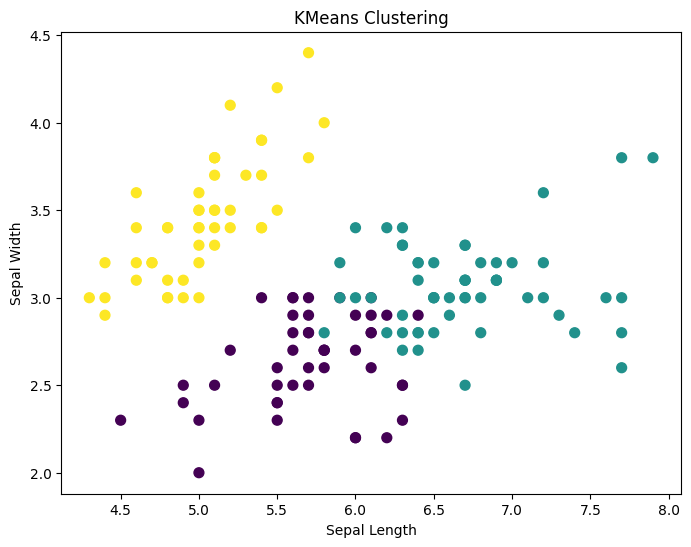

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df['sepal_length'], df['sepal_width'], c=df['cluster'], cmap='viridis', s=50)
plt.title('KMeans Clustering')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.show()